### Imports

In [28]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.nn as nn
import os
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np

In [2]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

/Users/marcinmarzejon/GitHub/lg-mode-classifier


In [3]:
from training.datasets import (
    get_indices, 
    get_class_labels, 
    calculate_transformation_params, 
    MyDataset,
    worker_init_fn,
    )
from training.train import train_one_epoch, train_model
from training.evaluation import evaluate_model, calculate_metrics, confusion_matrix
from training.predict import get_predictions
from models.ResNet18 import ResNet18

In [4]:
# Reproducibility
SEED = 42

torch.manual_seed(SEED)

# Device
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print(f"Using device: {device}")

# Training configuration
BATCH_SIZE = 64
NUM_EPOCHS = 30
LEARNING_RATE = 1e-5
PATIENCE = 5
MIN_DELTA = 1e-3

# Dataset
NUM_CLASSES = 6
N_IMAGES = 1_000

NUM_WORKERS = 2

Using device: mps


### Get data files for the model

In [5]:
files_dir = Path(PROJECT_ROOT, r'output/modes')
os.chdir(files_dir)

files = os.listdir()
files = [file for file in files if file[-3:]=='.h5']
for elem in files:
    elem = Path(files_dir, elem)

Train, test, and validation ratios

In [6]:
train_ratio = 0.75
test_ratio = 0.15

Generate datasets

In [7]:
indices_train, indices_test, indices_validate = [], [], []

for file in files:
    temp1, temp2, temp3 = get_indices((train_ratio, test_ratio),N=N_IMAGES)
    indices_train.append(temp1)
    indices_test.append(temp2)
    indices_validate.append(temp3)

In [8]:
classes_train, classes_test, classes_val = get_class_labels(indices_train, indices_test, indices_validate)

Training data transformation

In [9]:
tr_mean, tr_std = calculate_transformation_params(
    files, 
    indices_train, 
    # Adjust to your memory capabilities
    n_subset=1024
)

Transformation for train dataset

In [10]:
transform = transforms.Normalize(
    mean=(tr_mean,),
    std=(tr_std,)
)

Define datasets

In [11]:
train_dataset = MyDataset(
    files=files,
    indices=indices_train,
    transform=transform
)

validate_dataset = MyDataset(
    files=files,
    indices=indices_validate,
    transform=transform
)

test_dataset = MyDataset(
    files=files,
    indices=indices_test,
    transform=transform
)

Dataset loaders

In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    worker_init_fn=worker_init_fn,
)

validation_loader = DataLoader(
    validate_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    worker_init_fn=worker_init_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    worker_init_fn=worker_init_fn,
)

### ResNet18

Create model

In [13]:
model = ResNet18(num_classes=6)
model.to(device)

num_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {num_parameters:,}")

Trainable parameters: 11,173,318


In [14]:
criterion = nn.CrossEntropyLoss()

In [15]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

Train model

In [16]:
model, history = train_model(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS,
    num_classes=NUM_CLASSES,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
)

Epoch 1/30 | train loss: 0.9947 | val loss: 0.6132 | time: 2 min 34.1 s
Metrics: Accuracy: 0.8433 | Precision: 0.8730 | Recall: 0.8433 | F1-score: 0.8452 | AUROC: 0.9916
Epoch 2/30 | train loss: 0.4323 | val loss: 0.3783 | time: 3 min 57.4 s
Metrics: Accuracy: 0.8667 | Precision: 0.8843 | Recall: 0.8667 | F1-score: 0.8571 | AUROC: 0.9949
Epoch 3/30 | train loss: 0.2072 | val loss: 0.2083 | time: 3 min 31.3 s
Metrics: Accuracy: 0.9717 | Precision: 0.9735 | Recall: 0.9717 | F1-score: 0.9716 | AUROC: 0.9999
Epoch 4/30 | train loss: 0.0830 | val loss: 0.0617 | time: 3 min 7.5 s
Metrics: Accuracy: 0.9950 | Precision: 0.9951 | Recall: 0.9950 | F1-score: 0.9950 | AUROC: 1.0000
Epoch 5/30 | train loss: 0.0429 | val loss: 0.0274 | time: 2 min 51.2 s
Metrics: Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1-score: 1.0000 | AUROC: 1.0000
Epoch 6/30 | train loss: 0.0283 | val loss: 0.0185 | time: 2 min 54.1 s
Metrics: Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1-score: 1.00

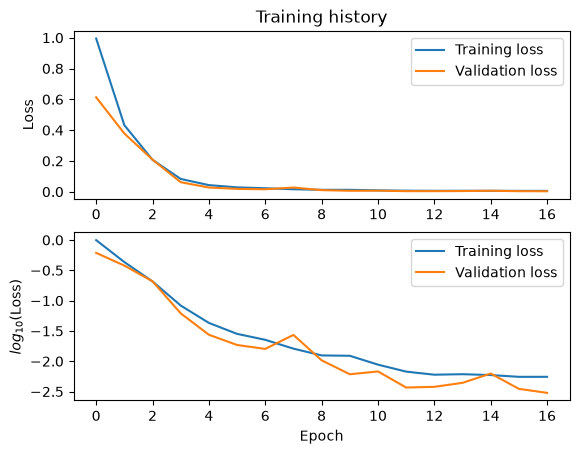

In [ ]:
plt.subplots(2, 1)

plt.subplot(2, 1, 1)
plt.plot(history["train_loss"], label="Training loss")
plt.plot(history["validation_loss"], label="Validation loss")
plt.ylabel("Loss")
plt.title("Training history")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(np.log10(history["train_loss"]), label="Training loss")
plt.plot(np.log10(history["validation_loss"]), label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("$log_{10}$(Loss)")
plt.legend()

plt.tight_layout
plt.show()

Model evaluation

In [18]:
val_loss, val_labels, val_predictions, val_probabilities = evaluate_model(
    model=model,
    loader=validation_loader,
    criterion=criterion,
    device=device,
)

In [19]:
val_metrics = calculate_metrics(
    predictions=val_predictions,
    probabilities=val_probabilities,
    target=val_labels,
    num_classes=NUM_CLASSES,
)

In [20]:
for name, value in val_metrics.items():
    print(f"{name}: {value.item():.4f}")

accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1: 1.0000
auroc: 1.0000


In [21]:
val_confusion_matrix = confusion_matrix(
    target=val_labels,
    predictions=val_predictions,
    num_classes=NUM_CLASSES,
)

print(val_confusion_matrix)

tensor([[100,   0,   0,   0,   0,   0],
        [  0, 100,   0,   0,   0,   0],
        [  0,   0, 100,   0,   0,   0],
        [  0,   0,   0, 100,   0,   0],
        [  0,   0,   0,   0, 100,   0],
        [  0,   0,   0,   0,   0, 100]])


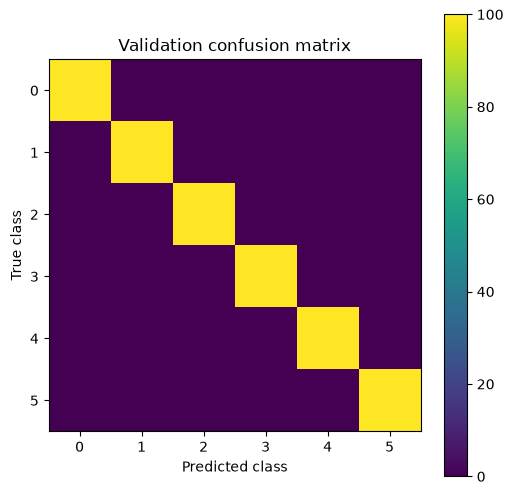

In [22]:
plt.figure(figsize=(6, 6))

plt.imshow(
    val_confusion_matrix.numpy()
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Validation confusion matrix")

plt.colorbar()

plt.show()

Testing model on unknown data

In [23]:
test_loss, test_labels, test_predictions, test_probabilities = evaluate_model(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
)

In [24]:
test_metrics = calculate_metrics(
    predictions=test_predictions,
    probabilities=test_probabilities,
    target=test_labels,
    num_classes=NUM_CLASSES,
)

for name, value in test_metrics.items():
    print(f"{name}: {value.item():.4f}")

accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1: 1.0000
auroc: 1.0000


In [25]:
test_confusion_matrix = confusion_matrix(
    target=test_labels,
    predictions=test_predictions,
    num_classes=NUM_CLASSES,
)

print(test_confusion_matrix)

tensor([[150,   0,   0,   0,   0,   0],
        [  0, 150,   0,   0,   0,   0],
        [  0,   0, 150,   0,   0,   0],
        [  0,   0,   0, 150,   0,   0],
        [  0,   0,   0,   0, 150,   0],
        [  0,   0,   0,   0,   0, 150]])


Saving the best model

In [26]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "num_classes": NUM_CLASSES,
        "learning_rate": LEARNING_RATE,
        "epoch": len(history["train_loss"]),
        "history": history,
    },

    "best_model_ResNet18.pth",
)

### CNN model